# How Basener and Sanford Got Their Results

In [Section 5.4](https://link.springer.com/article/10.1007%2Fs00285-017-1190-x#Sec17), Basener and Sanford indicate that zeroing relatively small frequencies, putatively for the sake of biological realism, is the critical factor in their observation that the population "collapses." We will establish that they obtained the desired result by introducing a gimmick, unreported in the article, for greatly reducing the fraction of mutations that have no effect on fitness. That is, when we eliminate either the (misreported) zeroing of relatively small frequencies or the unreported gimmick for reducing the incidence of neutral mutation, and leave all else the same, the population grows rather than shrinks in size. The gimmick is to set the probability that mutation has no effect on fitness to the much smaller probability that mutation has a minimally deleterious effect.

Our baseline in this demonstration is not the result that Basener and Sanford report, but instead the result obtained by correcting two errors in Basener's software. The errors are characterized formally in the notebook "Numerical Check of Theorem 2." As shown below, they cause the birth rates and the incidence of beneficial mutation to be much smaller than reported in the article. When the errors are corrected, the population still "collapses." Thus the baseline is essentially what Basener and Sanford would have reported if Basener had tested and debugged his code.

**Jupyter users: Select `Restart & Run All` in the `Kernel` tab.**

In [1]:
%matplotlib notebook
%run ../Code/bs.py

## Preliminaries

### What is a "collapsing" population?

It is impossible to respond to Basener and Sanford in their own terms, inasmuch as their terms are incoherent. They report dramatic change in the distribution of the population over growth rates (fitnesses), and maintain contradictorily that the population size is constant throughout the process:

>The mean fitness and variance are plotted in Fig. [12](https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig12_HTML.gif). This plot suggests that the fitness is decreasing steadily, but the variance increases, goes through a cusp, and then decreases (as the population collapses). This cusp occurs about the point where the mean fitness (growth rate) is zero. This is the point where the third and final stage of Lynch’s mutational meltdown model begins. While our population \[size\] is held at $10^{9},$ we still see the continuing decline in fitness. If the total population size were variable, it is likely that we would see compounding decline of a mutational meltdown.

Although this bafflegab is finely crafted, its absurdity is fairly easy to see. When the population is concentrated on negative growth rates, it is growing smaller in size, not staying the same in size. However, Basener and Sanford claim that their zeroing of relatively small frequencies, which is really no more than an ad hoc tweak of the software, yields a model of a process in which the population is unchanging in size. Thus, when it comes time to report that the size of the population tends to zero, they cannot do so without admitting that their characterization of the tweaked software as a model is bogus. They instead humiliate themselves by reporting that the population "collapses" without changing in size, and by suggesting that the population would "collapse" even more dramatically in the absence of their assertion that the size is unchanging.

### Misreporting of the frequency threshold

It becomes abundantly clear that the zeroing of small frequencies is an ad hoc tweak, akin to the unreported gimmick for reducing the incidence of neutral mutation, when we inspect Basener's script, and find that it does not operate as Basener and Sanford claim:

>Because the focus of this paper is on implications of the system for biological populations, we make a modification of Eq. ([3.2](https://link.springer.com/article/10.1007%2Fs00285-017-1190-x#Equ8)) that effectively restricts to finite-sized populations. To remain biologically realistic, we assume a finite population: any subpopulation $P_i$  that contains less than some fraction of the population is assumed to contain zero organisms. For the numerical simulations, we set $P_i = 0$ whenever $P_i$ is less than   $10^{-9}$  of the total population. This approximates a total population of $10^9$ and eliminates any subpopulation with less than a single organism. The only case where this made an observable difference was Sect. [5.4](https://link.springer.com/article/10.1007%2Fs00285-017-1190-x#Sec17). In that case, without the finite-population condition subpopulations remain viable even when they contain less than a fraction of an organism. As a result, extremely small, biologically nonsensical, populations control the observed results and obscure the effect of mutations on the population as a whole.

The script does not define "small" in relation to the size of the entire population, i.e., $\sum_i P_i,$ as Basener and Sanford indicate. but instead in relation to the maximum frequency of any type of organism in the population, i.e., $\max_i P_i.$ The types are defined by slicing the interval of growth factors into subintervals of equal length (which Basener and Sanford call subpopulations). If the frequency $P_i$ (coded as `Psolution[t][i]` in the following) of a type of organism does not exceed a billionth of the maximum frequency, then the script sets it to zero:

```javascript
if (PopSize == "Finite") {
    maximumP = Math.max.apply(Math, Psolution[t]);
    for (i = 0; i < numIncrements; i++) {
        Psolution[t][i] = Psolution[t][i] * (Psolution[t][i] > maximumP * 0.000000001);
    }
}
```

If the script had taken the sum instead of the maximum in the second line above, then it would have implemented the thresholding operation that Basener and Sanford described in the article.

As shown in the graphics below, the actual effect of the thresholding operation is to crop the tails of the frequency distribution of the population over growth rates. If the threshold were one-billionth the size of the population, as Basener and Sanford indicate, then it would be possible, by slicing the interval of growth rates into sufficiently many subintervals (subpopulations), to eliminate arbitrarily much of the tails. This speaks to the lameness of regarding a discrete approximation to a continuous model as a model of discrete phenomena. Basener has, by redefining the threshold frequency in terms of the maximum of the frequencies, reduced the sensitivity of the tail-cropping to the number of subintervals. He has not made it reasonable to regard the cropped tails as collections of fractional organisms. It remains the case that the frequencies of subintervals (treated as types of organism) depend on an arbitrary definition of the subintervals. There is nothing compelling us to slice the interval of growth rates one way, and not another.

Now we turn to the demonstration that both the misreported thresholding and the unreported gimmick are necessary for the population to "collapse" as Basener and Sanford report.

## Define the initial frequency distribution

We begin by setting up the initial frequency distribution for all experiments. With `density=True`, the probability mass of each growth factor is proportional to the probability density at that point. In all cases, not just this one, Basener approximates the area under the curve with the area of a rectangle.

In [2]:
factors = Factors(N_TYPES['Gamma'])
initial = GaussianFrequencies(factors, density=True)

## Define the distributions of probability over mutation effects

Basener's script features not only a gimmick to reduce the probability that mutation is neutral in effect, but also an erroneous reweighting of the distribution. The reweighting is supposed to make the probability that mutation is positive in effect equal to .001. It instead makes the norm of the distribution (sum of all probabilities) equal to 0.82, and associates probability mass of 0.00062 with beneficial mutations. Put simply, Basener's script silently kills many of the births, and greatly reduces the incidence of beneficial mutation in those that it does not kill.

Basener and Sanford did not need the botched reweighting to obtain the "collapsing" population of Section 5.4. Here we retain only the gimmick for reducing the probability that mutation has zero effect. The comments in the following cell provide a detailed explanation of the operations we are about to perform.

In [3]:
# %load ../Code/gamma.py
class Gamma(EffectsDistribution):
    """
    A discretized Gamma distribution and its reflection in the zero-effect axis.
    """
    def __init__(self, factors, alpha=0.5, beta=0.5/0.001, density=True,
                       normed=False):
        """
        Defines a symmetric Gamma distribution with the given parameters.
        
        The `factors` object is an instance of class `Factors`. The Boolean
        parameters `density` and `normed` determine, respectively, whether the
        density function or the cumulative distribution function is used in
        assignment of probability masses to effects, and whether the resulting
        distribution is normalized.
        """
        rv = stats.gamma(alpha, scale=1/beta)
        super().__init__(factors, rv, density=density, normed=normed)
    
    def zero_neutral(self):
        """
        Sets to zero the probability that mutation has no effect on fitness.
        """
        self.p[self.effect == 0] = 0
        
    def gimmick(self):
        """
        Assigns the probability of minimally deleterious effect to zero effect.
        """
        self.p[self.effect == 0] = self.p[self.effect < 0][-1]

    def reweight(self, beneficial=0.001, botched=False):
        """
        Sets the probability of positive effect to `beneficial` unless botched.
        
        If `botched` is false, then the probabilities of positive mutation
        effects are scaled so that they sum to `beneficial`, and the
        probabilities of non-positive effects are scaled so that they sum to
        1 - `beneficial`.
        
        If `botched` is true, then the probabilities of positive and non-
        positive effects are simply multiplied by `beneficial` and 1 -
        `beneficial`, respectively.
        """
        effect = self.effect
        if not botched:
            self.p[effect > 0] /= float(mp.fsum(self.p[effect > 0]))
            self.p[effect <= 0] /= float(mp.fsum(self.p[effect <= 0]))
        self.p[effect > 0] *= beneficial
        self.p[effect <= 0] *= 1 - beneficial

**Distribution described by Basener and Sanford**

In [4]:
no_gimmick = Gamma(factors)
effect = no_gimmick.domain
p = no_gimmick.p
math.fsum(p[effect > 0])

0.6024717944381728

In [5]:
no_gimmick.reweight(botched=False)

**Gimmicked distribution used in our baseline process**

In [6]:
gimmick = Gamma(factors)
gimmick.gimmick()
gimmick.reweight(botched=False)

**Botched, gimmicked distribution used by Basener and Sanford**

In [7]:
botched_gimmick = Gamma(factors)
botched_gimmick.gimmick()
botched_gimmick.reweight(botched=True)

If we were replicating, rather than correcting, the numerical experiment of Section 5.4, then we would make use of the `botched_gimmick` distribution instead of the `gimmick` distribution. Below, we will do the replication, in order to observe the effects of botching the reweighting of the gimmicked distribution. But our primary objective in this notebook is to establish what is *necessary* to obtain the "collapsing" population that Basener and Sanford report.

### Plot the distributions of probability over mutation effects

**Need to explain why the growth factors are nominal, and why I say 'factor' instead of 'rate.'**

<IPython.core.display.Javascript object>


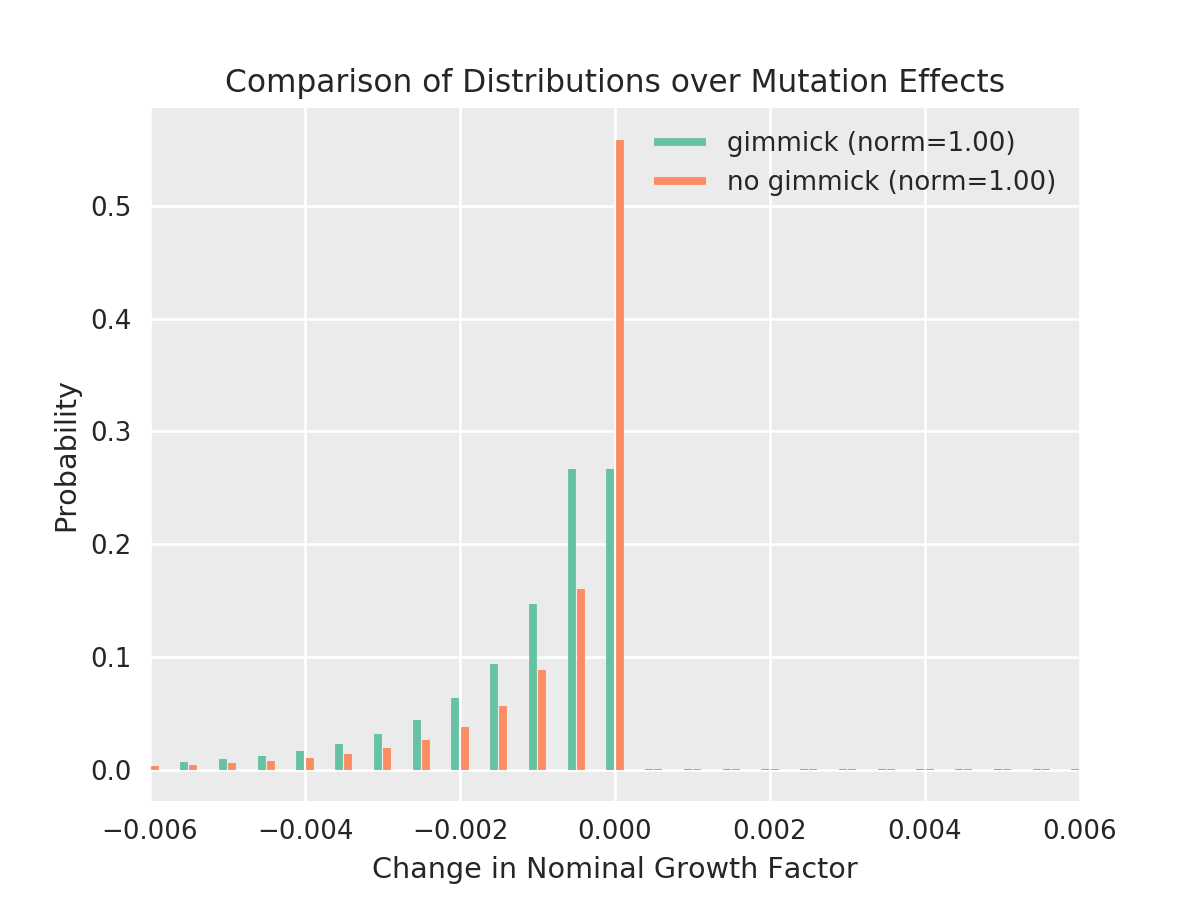

In [8]:
fig, ax = plt.subplots()
ax.set_title('Comparison of Distributions over Mutation Effects')
ax.set_xlim(-0.006, 0.006)
offset = 0.00006
label = 'gimmick (norm={0:.2f})'.format(gimmick.norm())
gimmick.vlines(ax, -offset, label, sns.color_palette()[0])
label = 'no gimmick (norm={0:.2f})'.format(no_gimmick.norm())
no_gimmick.vlines(ax, offset, label, sns.color_palette()[1])
ax.legend();

## Defining the processes to be compared

We will compare three processes. The baseline process features both the gimmick and thresholding, i.e., zeroing of frequencies that are small in relation to the maximum of the frequencies. There are two alternative processes, each of which differs from the baseline in only one way.

In [9]:
baseline = Evolution(Population(initial, gimmick, norm=np.max, label='baseline'))
sans_gimmick = Evolution(Population(initial, no_gimmick, norm=np.max, label='no gimmick'))
sans_threshold = Evolution(Population(initial, gimmick, norm=None, label='no threshold'))
comparison = Comparison([sans_threshold, sans_gimmick, baseline])
comparison.set_subtitle('\nB&S Need Both Gimmick and Threshold')
comparison(2500)

## Graphical comparison of baseline and alternative processes

Now we generate a grahical comparison of the three processes. With the number of frames (`nframes`) set to zero in the following cell, a static figure is generated instead of an animation. If you are connected to a Jupyter server, then you should set `nframes` to a positive number. Start with a small number, e.g., 25, to get oriented. Use the `n_years` parameter to restrict the animation to the earlier years of the processes. With `n_years=None`, all years are included. The `duration` of the animation is specified in milliseconds.

In the display of proportions (normalized frequencies), the curve for "no threshold" is hidden behind that for the baseline process for about 650 years. It is important to observe how the frequencies are changing (in the upper frame) at the time that the proportions diverge (in the lower frame).

<IPython.core.display.Javascript object>


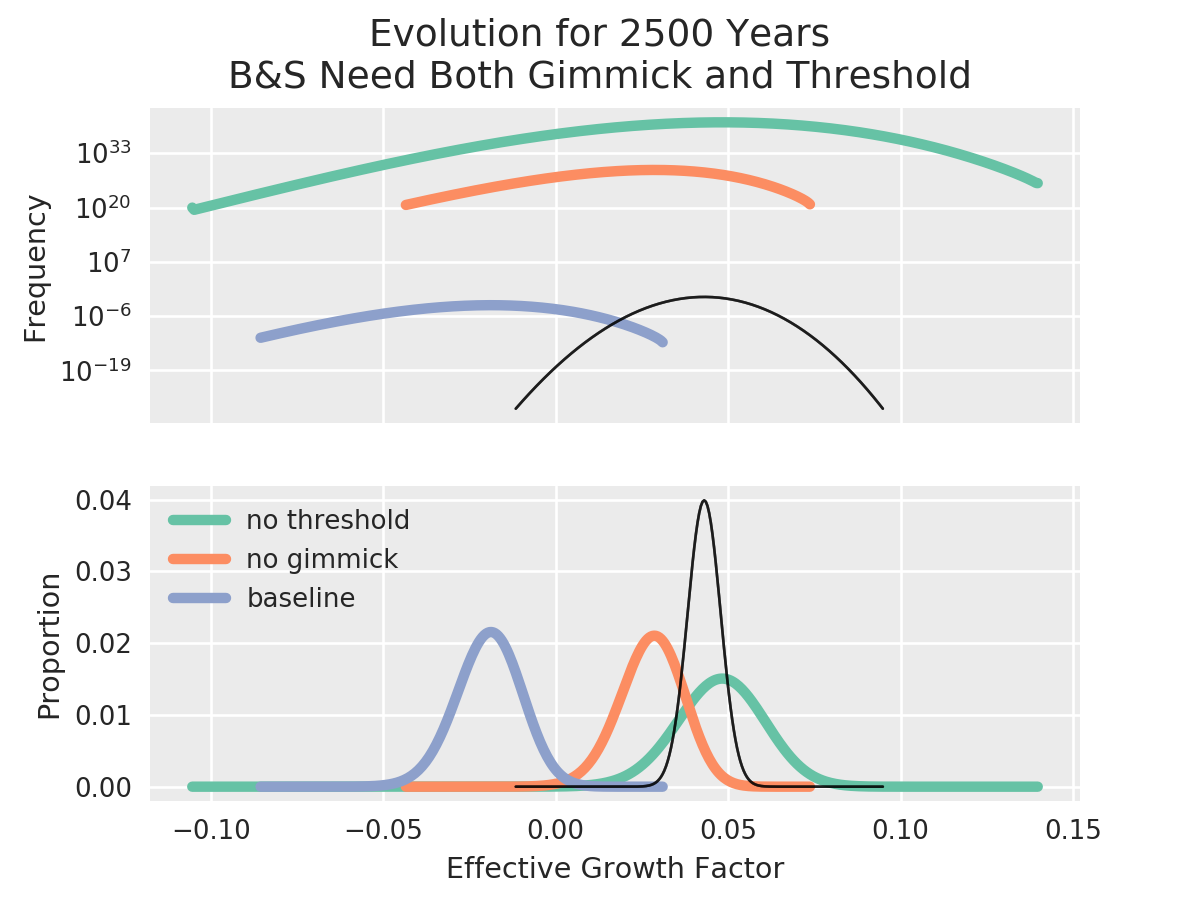

In [10]:
plt.rcParams['animation.embed_limit'] = 40 # megabytes
comparison.animate(nframes=0, duration=10000, effective=True, n_years=None)

The animation of three processes is at times visually confusing, so we also display pairwise comparisons of the alternative processes to the baseline process.

### Comparison of "no threshold" and baseline processes

<IPython.core.display.Javascript object>


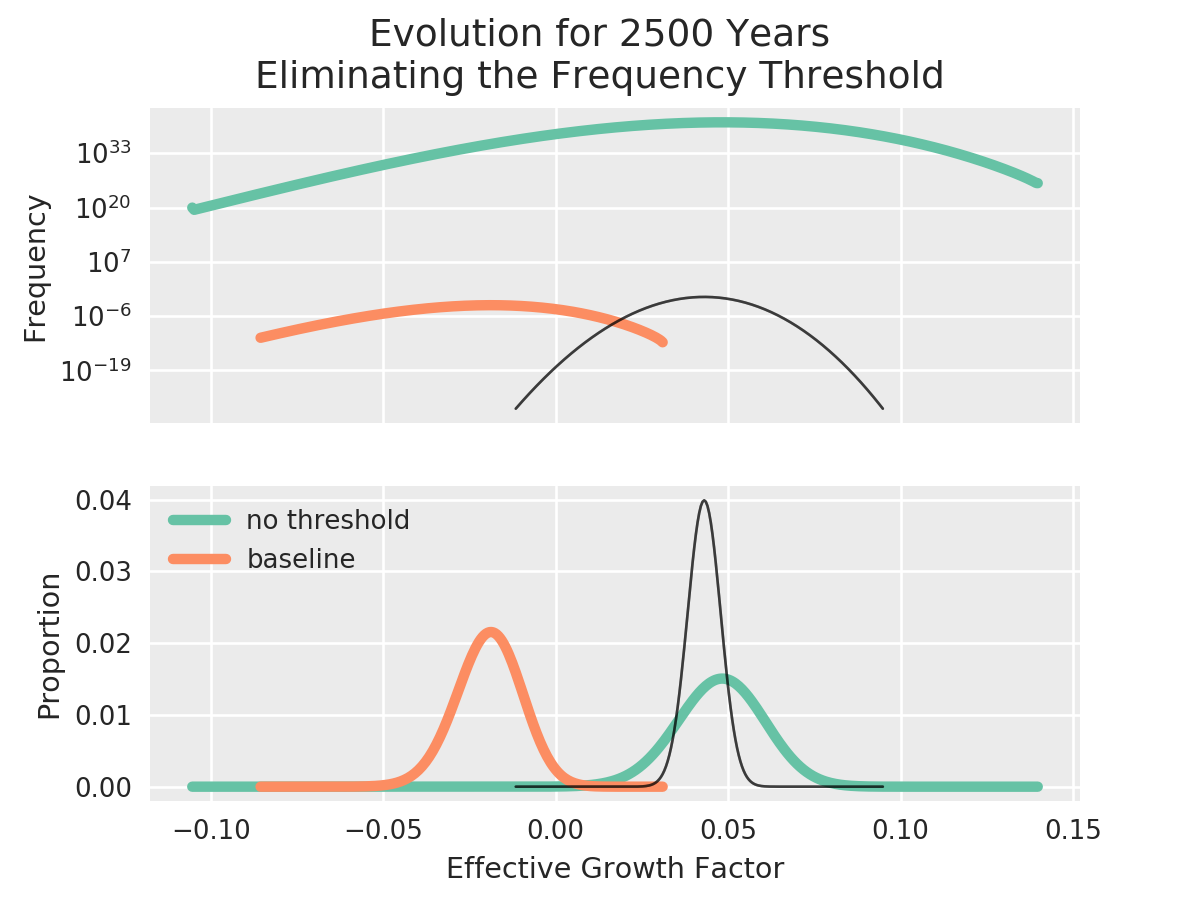

In [11]:
no_threshold_versus_bs = Comparison([sans_threshold, baseline])
no_threshold_versus_bs.set_subtitle('\nEliminating the Frequency Threshold')
no_threshold_versus_bs.animate(nframes=0, duration=10000, effective=True, n_years=None)

<IPython.core.display.Javascript object>


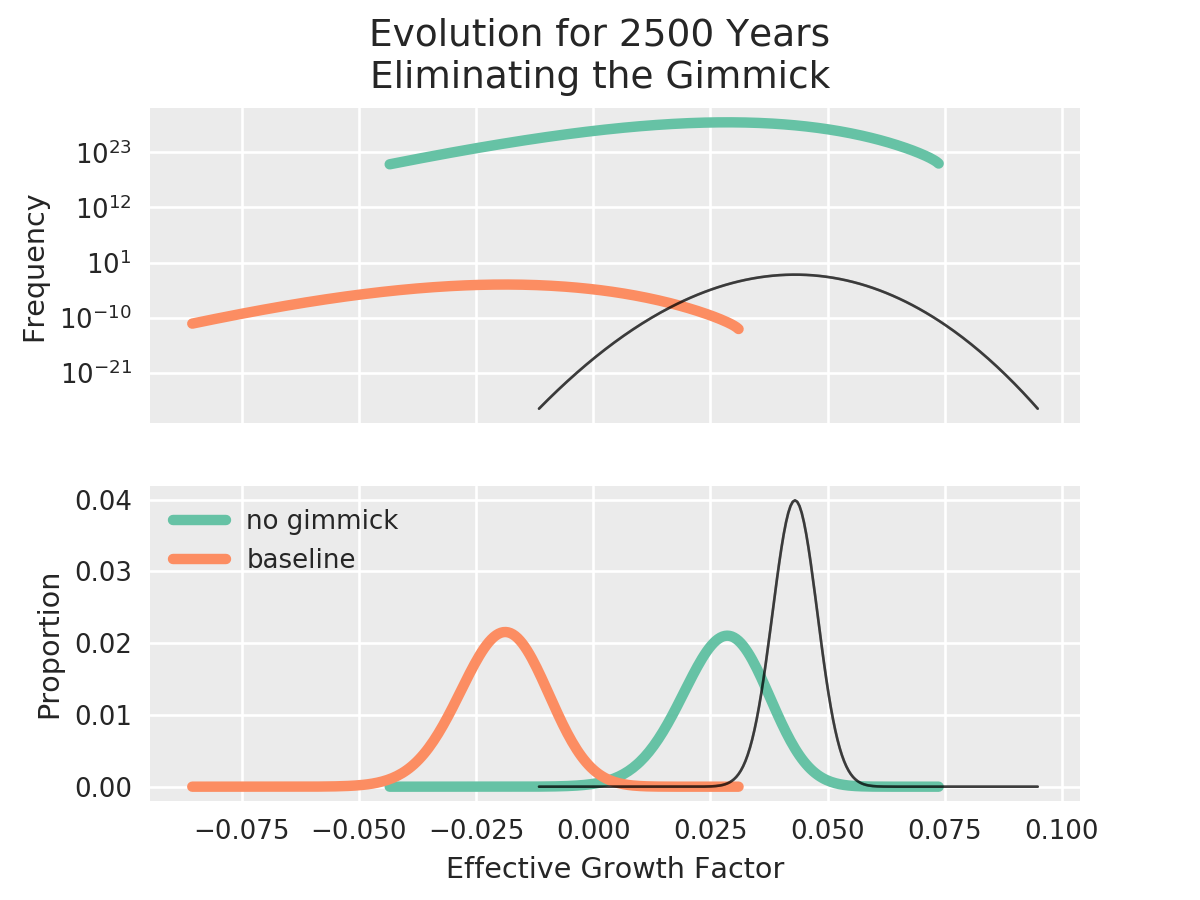

In [12]:
no_gimmick_versus_bs = Comparison([sans_gimmick, baseline])
no_gimmick_versus_bs.set_subtitle('\nEliminating the Gimmick')
no_gimmick_versus_bs.animate(nframes=0, duration=10000, effective=True, n_years=None)

## The botched process addressed in Section 5.4

Now we have a look at the process that Basener and Sanford address in Section 5.4. Recall that the reweighting of the gimmicked distribution is botched.

<IPython.core.display.Javascript object>


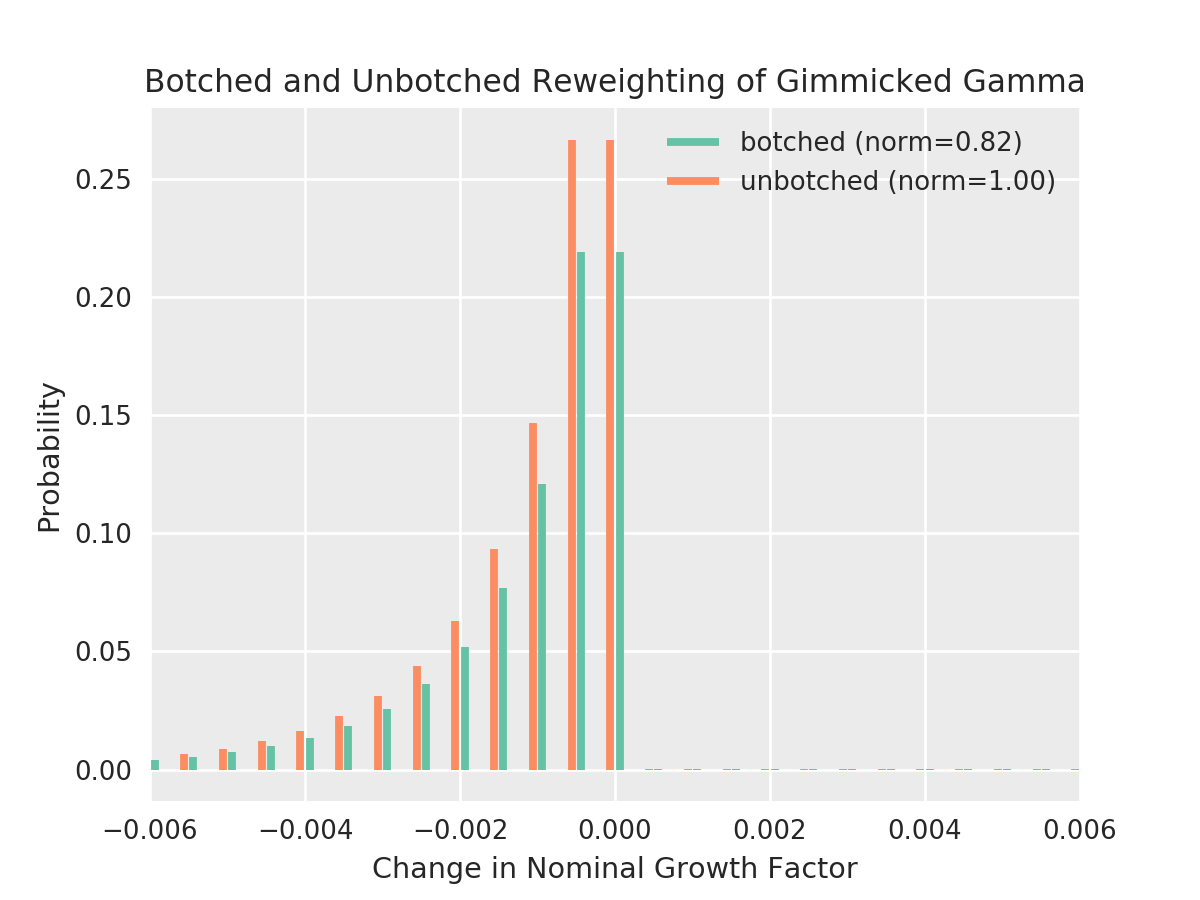

In [13]:
fig, ax = plt.subplots()
ax.set_title('Botched and Unbotched Reweighting of Gimmicked Gamma')
ax.set_xlim(-0.006, 0.006)
offset = 0.00006
label = 'botched (norm={0:.2f})'.format(botched_gimmick.norm())
botched_gimmick.vlines(ax, offset, label, sns.color_palette()[0])
label = 'unbotched (norm={0:.2f})'.format(gimmick.norm())
gimmick.vlines(ax, -offset, label, sns.color_palette()[1])
ax.legend();

When the norm of the distribution over mutation effects is 0.82, the birth factors are effectively reduced by 18 percent. Another error, described in "Numerical Check of Theorem 2," is replicated by setting `lossy=True` in the construction of the `Population` instance. The direct effect of the error is to reduce the frequencies of the types at the endpoints of the growth-rates interval. In the particular case we are considering, however, those frequencies never rise above threshold, even when the error is eliminated. Thus the setting of the `lossy` parameter has no effect on the results displayed below.

In [14]:
botched = Evolution(Population(initial, botched_gimmick, norm=np.max, lossy=True, label='botched'), 2500)

In [17]:
gimmick_versus_botched = Comparison([botched, baseline])
gimmick_versus_botched.set_subtitle('\nEffects of Botched Reweighting')
plt.rcParams['animation.html'] = 'html5'
gimmick_versus_botched.animate(nframes=50, duration=10000, effective=True, n_years=None)

## Conclusion

The results of Section 5.4 do not depend merely on the frequency threshold, as Basener and Sanford indicate, but also on an unreported gimmick for greatly reducing the probability that mutation has no effect on fitness. Neither the thresholding operation nor the gimmick alone results in the "collapsing" population that Basener and Sanford report.